<a href="https://colab.research.google.com/github/xiaann622/Analystlab/blob/Week-5/Telco_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telco Customer Churn — Business Analytics Case Study

**Business problem:** Why are customers leaving the company, and which factors contribute most to churn?

This notebook covers Steps 2 and 3 of the case study: data exploration, visualization, and key-driver identification.
Run the cells top to bottom in Google Colab.


## 0. Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)


## 1. Load the data

In Colab, upload the CSV first (left sidebar → Files → upload), or run the cell below to get an upload prompt.


In [2]:


df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,"1,889.50",No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,"1,840.75",No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Dataset Overview

Basic shape, column data types, and a first look at what we're working with.


In [3]:
print('Rows, Columns:', df.shape)
print()
print('Data types:')
print(df.dtypes)


Rows, Columns: (7043, 21)

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [4]:
df['TotalCharges']= pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [5]:
print('Missing values before cleaning (raw dtypes):')
print(df.isnull().sum().sum(), 'nulls detected as-is')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print()
print('Missing values after converting TotalCharges to numeric:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# These 11 are all tenure == 0 (new customers, not yet billed) -> fill with 0, not drop
print()
print('Tenure of rows with missing TotalCharges:')
print(df.loc[df['TotalCharges'].isnull(), 'tenure'].unique())
df['TotalCharges'] = df['TotalCharges'].fillna(0)


Missing values before cleaning (raw dtypes):
4150 nulls detected as-is

Missing values after converting TotalCharges to numeric:
TotalCharges    4150
dtype: int64

Tenure of rows with missing TotalCharges:
[34 45 22 28 62 58 49 25 69 52 71 21 30 47 72 17 27 46 11 70 63 43 15 60
 18 66 31 64 56 42 35 48 29 65 38 68 55 37 36 10 33 13 67 23 57 61 14 16
 20 53 40 59 44 19 24 54 50 41 51 32 26  0 12 39]


In [6]:
# Recode SeniorCitizen from 0/1 to No/Yes so it reads consistently with the other Yes/No columns
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# Duplicate check
print('Duplicate customerIDs:', df['customerID'].duplicated().sum())


Duplicate customerIDs: 0


## 4. Summary Statistics


In [7]:
print('Numeric summary:')
display(df[['tenure','MonthlyCharges','TotalCharges']].describe().round(2))

print()
print('Churn split:')
print(df['Churn'].value_counts())
print((df['Churn'].value_counts(normalize=True) * 100).round(1))


Numeric summary:


,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,147.29
std,24.56,30.09,256.98
min,0.00,18.25,0.00
25%,9.00,35.50,0.00
50%,29.00,70.35,0.00
75%,55.00,89.85,185.58
max,72.00,118.75,999.90



Churn split:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


## 5. Distribution of Key Variables

### 5.1 Overall churn (pie chart)


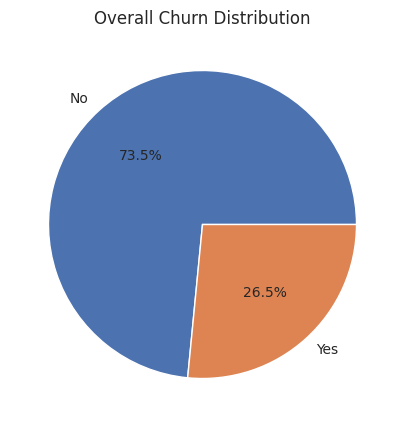

In [8]:
fig, ax = plt.subplots(figsize=(5,5))
df['Churn'].value_counts().plot.pie(
    autopct='%1.1f%%', colors=['#4C72B0','#DD8452'], ylabel='', ax=ax)
ax.set_title('Overall Churn Distribution')
plt.show()


### 5.2 Tenure and Monthly Charges (histograms)


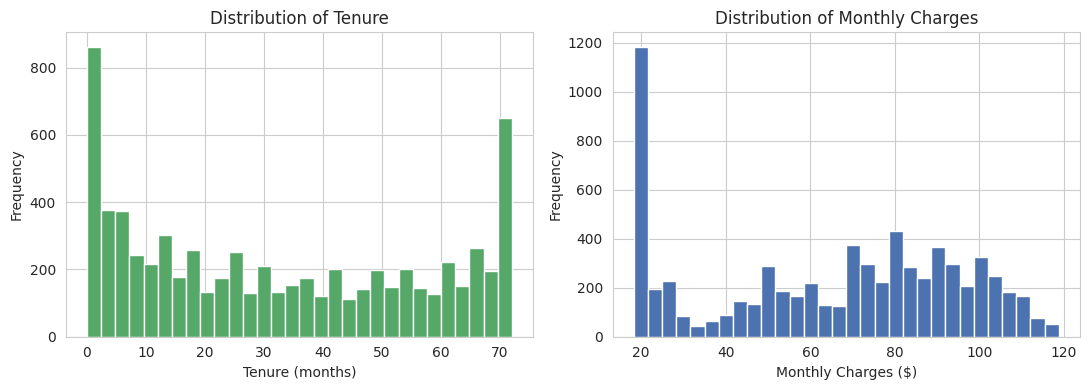

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
df['tenure'].plot.hist(bins=30, ax=axes[0], color='#55A868')
axes[0].set_xlabel('Tenure (months)'); axes[0].set_title('Distribution of Tenure')

df['MonthlyCharges'].plot.hist(bins=30, ax=axes[1], color='#4C72B0')
axes[1].set_xlabel('Monthly Charges ($)'); axes[1].set_title('Distribution of Monthly Charges')
plt.tight_layout(); plt.show()


### 5.3 Key categorical variables (bar charts)


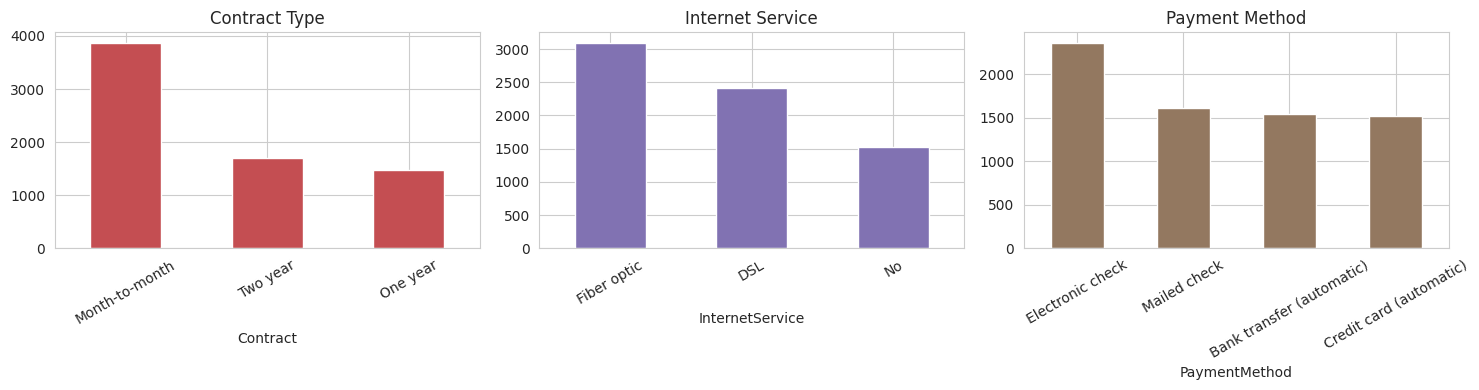

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
df['Contract'].value_counts().plot.bar(ax=axes[0], color='#C44E52'); axes[0].set_title('Contract Type'); axes[0].tick_params(axis='x', rotation=30)
df['InternetService'].value_counts().plot.bar(ax=axes[1], color='#8172B2'); axes[1].set_title('Internet Service'); axes[1].tick_params(axis='x', rotation=30)
df['PaymentMethod'].value_counts().plot.bar(ax=axes[2], color='#937860'); axes[2].set_title('Payment Method'); axes[2].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()


## 6. Churn vs. Key Drivers (bivariate analysis)

### 6.1 Churn rate by Contract, Internet Service, and Payment Method


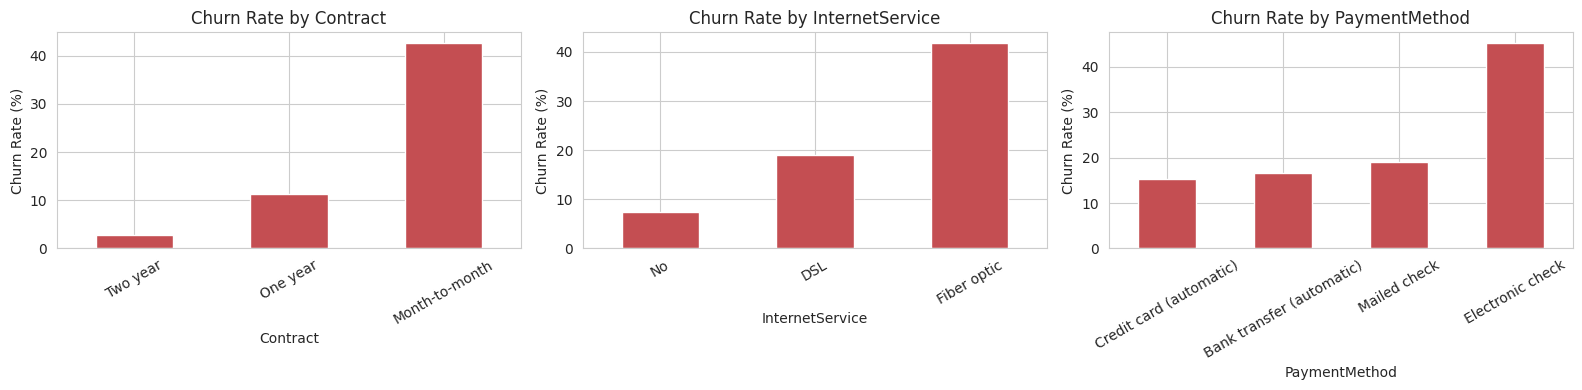

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))

for ax, col in zip(axes, ['Contract','InternetService','PaymentMethod']):
    rate = df.groupby(col)['Churn'].apply(lambda s: (s=='Yes').mean()*100).sort_values()
    rate.plot.bar(ax=ax, color='#C44E52')
    ax.set_ylabel('Churn Rate (%)'); ax.set_title(f'Churn Rate by {col}')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()


### 6.2 Tenure and Monthly Charges by churn status (box plots)


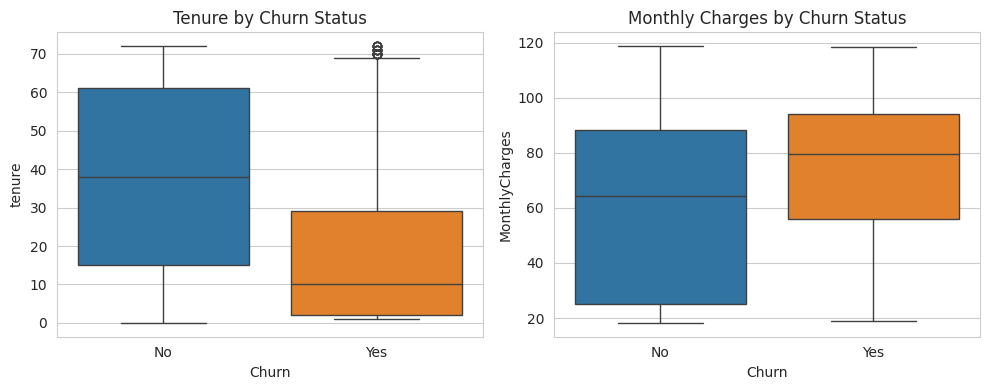

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.boxplot(data=df, x='Churn', y='tenure', hue='Churn', legend=False, ax=axes[0])
axes[0].set_title('Tenure by Churn Status')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', legend=False, ax=axes[1])
axes[1].set_title('Monthly Charges by Churn Status')
plt.tight_layout(); plt.show()


### 6.3 Churn rate trend across tenure (line chart)

Grouping tenure into 12-month buckets shows how churn risk falls as the relationship matures.


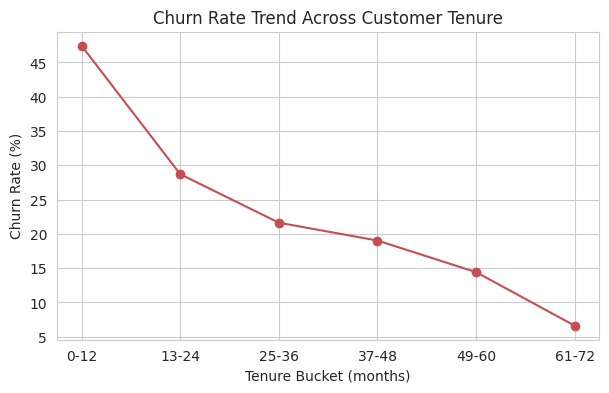

tenure_bucket
0-12     47.4
13-24    28.7
25-36    21.6
37-48    19.0
49-60    14.4
61-72     6.6
Name: Churn, dtype: float64


In [13]:
bins = [0,12,24,36,48,60,72]
labels = ['0-12','13-24','25-36','37-48','49-60','61-72']
df['tenure_bucket'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)

trend = df.groupby('tenure_bucket', observed=True)['Churn'].apply(lambda s: (s=='Yes').mean()*100)

fig, ax = plt.subplots(figsize=(7,4))
trend.plot(marker='o', ax=ax, color='#C44E52')
ax.set_ylabel('Churn Rate (%)'); ax.set_xlabel('Tenure Bucket (months)')
ax.set_title('Churn Rate Trend Across Customer Tenure')
plt.show()
print(trend.round(1))


## 7. Correlation Heatmap


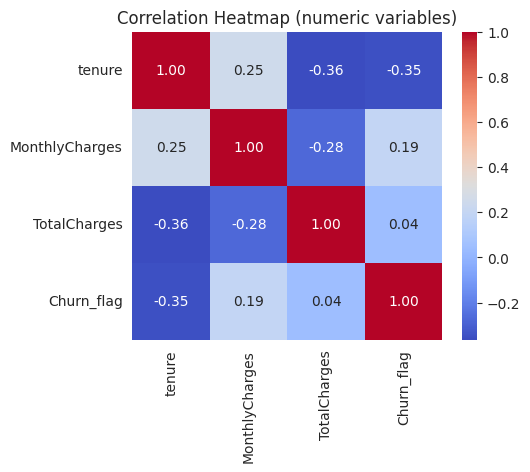

In [14]:
num = df[['tenure','MonthlyCharges','TotalCharges']].copy()
num['Churn_flag'] = (df['Churn'] == 'Yes').astype(int)

fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(num.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap (numeric variables)')
plt.show()


Correlation alone under-represents categorical drivers like Contract or Internet Service, since those aren't numeric. Section 8 uses statistical tests built for categorical variables instead.


## 8. Statistical Identification of Key Drivers

### 8.1 Chi-square test of independence

For each categorical variable, this tests whether churn is independent of that variable. A higher chi-square statistic (and a p-value below 0.05) means the variable is significantly associated with churn. We rank all variables by chi-square to see which matter most.


In [15]:
cat_cols = ['gender','SeniorCitizen','Partner','Dependents','PhoneService','MultipleLines',
            'InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport',
            'StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod']

results = []
for col in cat_cols:
    # Create a temporary DataFrame with only the current column and 'Churn', dropping any NaNs
    temp_df = df[[col, 'Churn']].dropna()

    # Check if temp_df is empty, which would lead to an empty contingency table
    if temp_df.empty:
        print(f"Skipping chi2_contingency for '{col}' due to no valid data after dropping NaNs.")
        continue

    ct = pd.crosstab(temp_df[col], temp_df['Churn'])

    # Check if the contingency table is empty after creation (e.g., if one category is completely absent)
    if ct.empty:
        print(f"Skipping chi2_contingency for '{col}' as the contingency table is empty.")
        continue

    chi2, p, dof, exp = chi2_contingency(ct)
    results.append((col, chi2, p))

chi_df = pd.DataFrame(results, columns=['feature','chi2','p_value']).sort_values('chi2', ascending=False)
display(chi_df)

,feature,chi2,p_value
13,Contract,1184.596572,5.863038e-258
7,OnlineSecurity,849.998968,2.661150e-185
10,TechSupport,828.197068,1.443084e-180
6,InternetService,732.309590,9.571788e-160
15,PaymentMethod,648.142327,3.682355e-140
8,OnlineBackup,601.812790,2.079759e-131
9,DeviceProtection,558.419369,5.505219e-122
12,StreamingMovies,375.661479,2.667757e-82
11,StreamingTV,374.203943,5.528994e-82
14,PaperlessBilling,258.277649,4.073355e-58


### 8.2 Logistic regression — direction and relative strength of each driver

Chi-square tells us *whether* a variable matters. Logistic regression tells us the *direction* — does having this attribute increase or decrease the odds of churn, holding the other variables constant? Numeric variables are standardized first so their coefficients are comparable to the categorical dummy variables.


In [16]:
model_df = df.copy()
model_df['Churn_flag'] = (model_df['Churn'] == 'Yes').astype(int)

X = pd.get_dummies(model_df[cat_cols + ['tenure','MonthlyCharges','TotalCharges']], drop_first=True)
y = model_df['Churn_flag']

num_cols = ['tenure','MonthlyCharges','TotalCharges']
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

lr = LogisticRegression(max_iter=2000)
lr.fit(X, y)
coefs = pd.Series(lr.coef_[0], index=X.columns).sort_values()

print('Top 10 factors that INCREASE churn odds:')
print(coefs.tail(10).round(3))
print()
print('Top 10 factors that DECREASE churn odds:')
print(coefs.head(10).round(3))


Top 10 factors that INCREASE churn odds:
gender_Male                      -0.024
Partner_Yes                       0.003
DeviceProtection_Yes              0.017
SeniorCitizen_Yes                 0.208
StreamingTV_Yes                   0.304
PaymentMethod_Electronic check    0.311
StreamingMovies_Yes               0.317
MultipleLines_Yes                 0.320
PaperlessBilling_Yes              0.349
InternetService_Fiber optic       0.982
dtype: float64

Top 10 factors that DECREASE churn odds:
Contract_Two year                      -1.286
tenure                                 -0.905
Contract_One year                      -0.645
PhoneService_Yes                       -0.525
OnlineSecurity_Yes                     -0.341
TechSupport_Yes                        -0.319
Dependents_Yes                         -0.165
TotalCharges                           -0.146
DeviceProtection_No internet service   -0.134
TechSupport_No internet service        -0.134
dtype: float64


**Reading note:** `MonthlyCharges` and `TotalCharges` are correlated with `tenure` (long-tenure customers accumulate high `TotalCharges`), so their regression coefficients can look counterintuitive in isolation. For the business narrative, lean on the bivariate churn rates in Section 6 (which are easy to explain to stakeholders) and use the chi-square ranking and regression direction as supporting statistical evidence.


## 9. Key Findings Summary

- **Overall churn rate: 26.5%** (1,869 of 7,043 customers) — a material share of the base.
- **Contract type is the single strongest driver.** Month-to-month churn is **42.7%**, vs. **11.3%** for one-year and just **2.8%** for two-year contracts.
- **Tenure matters just as much.** Customers who churn have an average tenure of **18 months** vs. **37.6 months** for those who stay; churn risk drops from **47.4%** in the first year to **6.6%** after 5 years.
- **Fiber optic internet customers churn more** (**41.9%**) than DSL (**19.0%**) or no-internet customers (**7.4%**), despite fiber being the premium product — worth investigating service quality or price-to-value perception.
- **Missing support add-ons predict churn.** No `OnlineSecurity` → **41.8%** churn vs. **14.6%** with it; no `TechSupport` → **41.6%** vs. **15.2%** with it.
- **Electronic check payers churn far more** (**45.3%**) than automatic bank transfer (**16.7%**) or credit card (**15.2%**) payers — friction/manual payment is a red flag.
- **Monthly charges are higher for churners** on average (**$74.44 vs. $61.27**), consistent with fiber/no-add-on customers paying more per month for less perceived value.
